# Reproducible workflow: Permutation entropy of white noise and Brown noise

This notebook is a small, fully reproducible toy workflow comparing the **normalized permutation entropy** of two stochastic processes:

- **White noise**: independent Gaussian samples.
- **Brown noise**: a discrete random walk obtained by cumulatively summing Gaussian innovations.

For each process, we generate **10 independent realizations**, each containing **\(10^6\) samples**, and compute permutation entropy with embedding dimension **\(m=4\)**. The final comparison reports the **mean and sample standard deviation** across the 10 realizations and visualizes both the time-series structure and the entropy estimates.

The workflow uses only synthetic data, so no external data files are required.

## How to run this workflow

1. Install Conda/Miniconda.
2. Create the environment from the accompanying `environment.yml`:

```bash
conda env create -f environment.yml
conda activate permutation-entropy-workflow
```

3. Start JupyterLab:

```bash
jupyter lab
```

4. Open `permutation_entropy_white_vs_brown.ipynb`.
5. Run all cells from top to bottom.

The random number generator is initialized with a fixed seed, so repeated runs with the same software environment should reproduce the same numerical results.

## 1. Imports and software versions

Reproducibility depends not only on code and random seeds, but also on the software environment. The cell below prints the Python and package versions used when the notebook is executed.

In [1]:
import sys
import platform
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt

print(f"Python:     {sys.version.split()[0]}")
print(f"NumPy:      {np.__version__}")
print(f"pandas:     {pd.__version__}")
print(f"Matplotlib: {matplotlib.__version__}")
print(f"Platform:   {platform.platform()}")

Python:     3.13.5
NumPy:      2.3.5
pandas:     2.2.3
Matplotlib: 3.10.8
Platform:   Linux-6.18.35-x86_64-with-glibc2.41


## 2. Experimental design

We use the following fixed parameters:

- Number of samples per realization: \(N = 10^6\)
- Number of independent realizations per process: \(n = 10\)
- Permutation-entropy embedding dimension: \(m = 4\)
- Time delay: \(\tau = 1\)
- Random seed: fixed below

For \(m=4\), there are

\[
m! = 4! = 24
\]

possible ordinal patterns.

White noise is generated as

\[
x_t \sim \mathcal{N}(0,1),
\]

independently for each \(t\).

Brown noise is generated as a random walk,

\[
y_t = y_{t-1} + \varepsilon_t,
\qquad
\varepsilon_t \sim \mathcal{N}(0,1).
\]

Brown noise is therefore strongly locally persistent, whereas white noise has no temporal dependence.

In [2]:
N_SAMPLES = 1_000_000
N_REPLICATES = 10
EMBEDDING_DIMENSION = 4
SEED = 20260911

assert EMBEDDING_DIMENSION == 4, "This implementation is optimized specifically for m=4."

## 3. Permutation entropy

Permutation entropy replaces amplitudes by the **ordinal pattern** of successive samples.

For embedding dimension \(m\), let \(p_i\) denote the observed relative frequency of ordinal pattern \(i\). The permutation entropy is

\[
H = -\sum_{i=1}^{m!} p_i \ln(p_i).
\]

To make results easier to compare, we normalize by the maximum possible entropy,

\[
H_\mathrm{norm}
=
\frac{H}{\ln(m!)}.
\]

Thus,

\[
0 \le H_\mathrm{norm} \le 1.
\]

A value close to 1 means that the available ordinal patterns occur with nearly equal probability. A lower value means that some temporal orderings are preferred over others.

### Implementation detail

Because the exercise fixes \(m=4\), the function below uses the **Lehmer rank** of each four-sample ordinal pattern. This avoids constructing a large \(N \times 4\) matrix and keeps memory use modest even for \(10^6\) samples.

The input distributions are continuous, so exact ties have probability zero in theory and are practically absent here.

In [3]:
def permutation_entropy_m4(x):
    """Return normalized permutation entropy for a 1D series at m=4, tau=1.

    The ordinal pattern of each four-point window is converted to a
    Lehmer-code rank from 0 to 23. The entropy of the resulting pattern
    frequencies is normalized by log(4!).
    """
    x = np.asarray(x, dtype=float)

    if x.ndim != 1:
        raise ValueError("x must be one-dimensional.")
    if x.size < 4:
        raise ValueError("x must contain at least four samples.")

    # Four overlapping views of consecutive samples.
    a = x[:-3]
    b = x[1:-2]
    c = x[2:-1]
    d = x[3:]

    # Lehmer-code digits. For continuous data, ties are practically absent.
    l0 = (
        (b < a).astype(np.int8)
        + (c < a).astype(np.int8)
        + (d < a).astype(np.int8)
    )
    l1 = (
        (c < b).astype(np.int8)
        + (d < b).astype(np.int8)
    )
    l2 = (d < c).astype(np.int8)

    # Rank each of the 24 possible permutations.
    rank = l0 * 6 + l1 * 2 + l2

    counts = np.bincount(rank, minlength=24)
    probabilities = counts[counts > 0] / counts.sum()

    entropy = -np.sum(probabilities * np.log(probabilities))
    normalized_entropy = entropy / np.log(24)

    return normalized_entropy

## 4. Generate the stochastic processes and compute entropy

A `SeedSequence` is used to create independent, reproducible random-number streams. White-noise and Brown-noise realizations are generated independently.

Only a short preview from the first realization is retained for plotting. The full \(10^6\)-sample arrays are processed one at a time and then discarded, which avoids unnecessary memory use.

In [4]:
seed_sequence = np.random.SeedSequence(SEED)
child_seeds = seed_sequence.spawn(2 * N_REPLICATES)

records = []
preview_length = 2_000
preview_white = None
preview_brown = None

for replicate in range(N_REPLICATES):
    rng_white = np.random.default_rng(child_seeds[2 * replicate])
    rng_brown = np.random.default_rng(child_seeds[2 * replicate + 1])

    white = rng_white.standard_normal(N_SAMPLES)
    brown = np.cumsum(rng_brown.standard_normal(N_SAMPLES))

    h_white = permutation_entropy_m4(white)
    h_brown = permutation_entropy_m4(brown)

    records.append({
        "replicate": replicate + 1,
        "process": "White noise",
        "permutation_entropy": h_white,
    })
    records.append({
        "replicate": replicate + 1,
        "process": "Brown noise",
        "permutation_entropy": h_brown,
    })

    if replicate == 0:
        preview_white = white[:preview_length].copy()
        preview_brown = brown[:preview_length].copy()

results = pd.DataFrame(records)
results

,replicate,process,permutation_entropy
0,1,White noise,0.999997
1,1,Brown noise,0.938594
2,2,White noise,0.999999
3,2,Brown noise,0.939106
4,3,White noise,0.999998
5,3,Brown noise,0.938605
6,4,White noise,0.999997
7,4,Brown noise,0.938534
8,5,White noise,0.999997
9,5,Brown noise,0.939131


## 5. Summary statistics

For each process, the table reports the mean normalized permutation entropy and the **sample standard deviation** across the 10 independent realizations.

In [5]:
summary = (
    results.groupby("process", sort=False)["permutation_entropy"]
    .agg(["mean", "std"])
    .rename(columns={"mean": "mean_PE", "std": "std_PE"})
)

summary["n"] = N_REPLICATES
summary

,mean_PE,std_PE,n
process,,,
White noise,0.999997,0.000001,10
Brown noise,0.938755,0.000227,10


## 6. Visualization of the stochastic processes

The first 500 samples of the first realization are shown below. For visual comparison only, each displayed segment is standardized to zero mean and unit standard deviation. This standardization is **not** used in the entropy calculation.

White noise should fluctuate without visible persistence, whereas Brown noise should show smoother local excursions because each value contains the accumulated history of previous innovations.

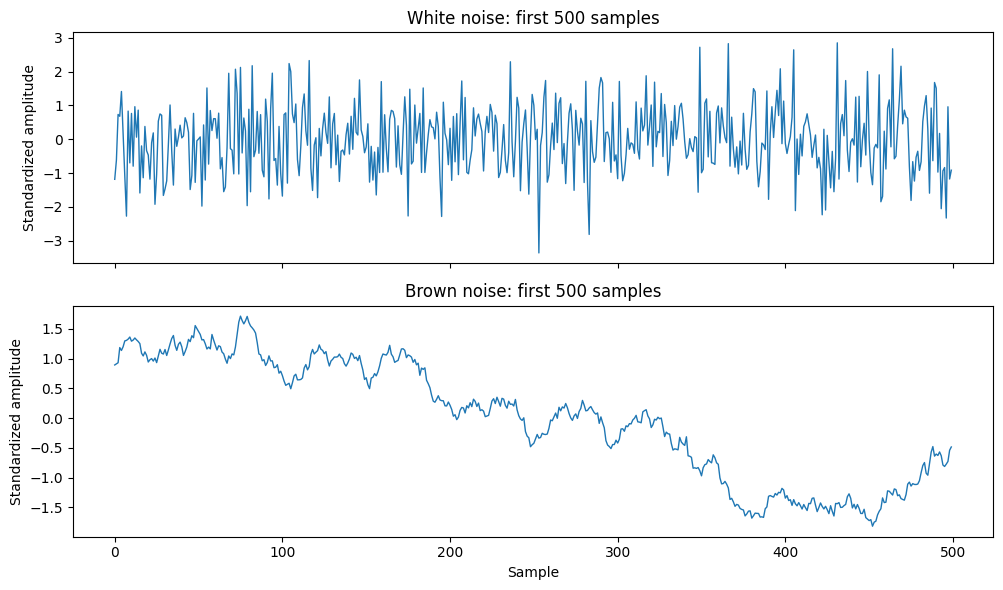

In [6]:
n_show = 500

white_plot = preview_white[:n_show]
brown_plot = preview_brown[:n_show]

white_plot = (white_plot - white_plot.mean()) / white_plot.std(ddof=1)
brown_plot = (brown_plot - brown_plot.mean()) / brown_plot.std(ddof=1)

fig, axes = plt.subplots(2, 1, figsize=(10, 6), sharex=True)

axes[0].plot(white_plot, linewidth=1)
axes[0].set_title("White noise: first 500 samples")
axes[0].set_ylabel("Standardized amplitude")

axes[1].plot(brown_plot, linewidth=1)
axes[1].set_title("Brown noise: first 500 samples")
axes[1].set_xlabel("Sample")
axes[1].set_ylabel("Standardized amplitude")

fig.tight_layout()
plt.show()

## 7. Comparison of permutation entropy

The figure below shows every replicate as a point. The larger marker and error bar show the **mean \(\pm\) one sample standard deviation** across the 10 realizations.

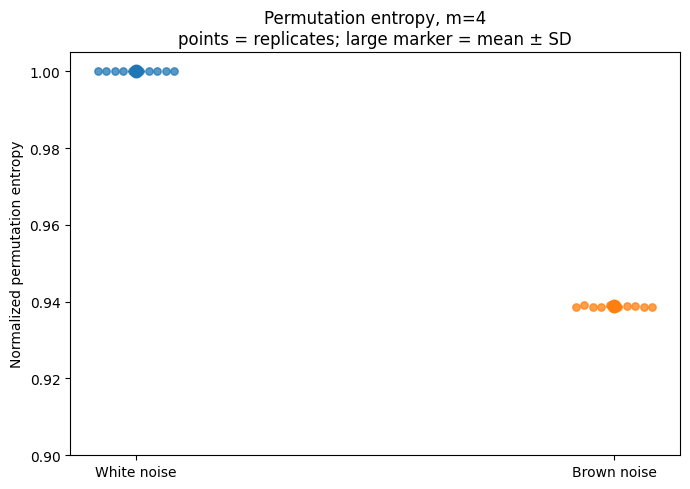

In [7]:
process_order = ["White noise", "Brown noise"]
x_positions = np.arange(len(process_order))

fig, ax = plt.subplots(figsize=(7, 5))

for x_pos, process in zip(x_positions, process_order):
    values = results.loc[
        results["process"] == process,
        "permutation_entropy"
    ].to_numpy()

    # Small deterministic horizontal offsets make overlapping replicate points visible.
    offsets = np.linspace(-0.08, 0.08, len(values))
    ax.scatter(
        np.full_like(values, x_pos, dtype=float) + offsets,
        values,
        s=28,
        alpha=0.75,
        label=None,
    )

    mean_value = values.mean()
    std_value = values.std(ddof=1)

    ax.errorbar(
        x_pos,
        mean_value,
        yerr=std_value,
        fmt="o",
        markersize=9,
        capsize=6,
        linewidth=2,
    )

ax.set_xticks(x_positions, process_order)
ax.set_ylabel("Normalized permutation entropy")
ax.set_title("Permutation entropy, m=4\npoints = replicates; large marker = mean ± SD")
ax.set_ylim(0.90, 1.005)

fig.tight_layout()
plt.show()

## 8. Interpretation

For Gaussian white noise, the 24 possible ordinal patterns at \(m=4\) are expected to occur with almost equal probability. Its normalized permutation entropy should therefore be very close to 1.

Brown noise is generated by integrating Gaussian innovations. Consecutive values are strongly dependent, so some ordinal patterns are more likely than others. Its permutation entropy is therefore expected to be lower than that of white noise.

This toy example illustrates that permutation entropy is sensitive to **temporal ordering**, not simply to the marginal amplitude distribution.

The analysis is descriptive: the 10 realizations are used to illustrate between-realization variability through the mean and standard deviation rather than to perform a formal hypothesis test.

## 9. Reproducible computing environment and version pinning

The accompanying `environment.yml` pins exact package versions. Exact pinning was chosen here because this is a small teaching workflow with only a few dependencies, and the goal is to make the computational environment as reproducible as practical.

The main risk is that exact old versions may become difficult to install on future operating systems or hardware. Conversely, leaving versions completely unpinned increases the risk that API changes or altered numerical behavior will change or break the workflow.

Semantic Versioning commonly uses the form

\[
\text{MAJOR.MINOR.PATCH}.
\]

In that convention:

- **MAJOR** changes may introduce incompatible API changes.
- **MINOR** changes add backward-compatible functionality.
- **PATCH** changes contain backward-compatible bug fixes.

However, not every scientific Python package follows Semantic Versioning perfectly, so version numbers reduce risk but do not eliminate it.

### Dependency risk assessment

| Dependency | Role in this workflow | Risk if future versions change | Reason |
|---|---|---:|---|
| Python | Executes the workflow | High | Language and standard-library behavior can change across major/minor releases. |
| NumPy | RNG, arrays, entropy calculation | High | Numerical APIs and random-number behavior are central to the analysis. |
| pandas | Results tables | Medium | Mostly affects data handling and display rather than the entropy algorithm. |
| Matplotlib | Figures | Low–Medium | Plotting APIs and default appearance can change without altering the numerical result. |
| JupyterLab / IPython kernel | Notebook execution | Medium | Mainly affects execution infrastructure and display compatibility. |

A useful long-term preservation strategy would be to keep the pinned environment file in the repository and create a versioned release of the repository.

## 10. Relation to the FAIR principles

FAIR stands for **Findable, Accessible, Interoperable, and Reusable**.

### Findable

A public repository can provide a descriptive repository name, README, keywords/topics, release tags, and other metadata. Archiving a release in a service such as Zenodo can additionally provide a persistent DOI.

### Accessible

The complete workflow can be downloaded from the repository. No private or proprietary input data are required because all data are generated within the notebook from a documented random seed.

### Interoperable

The workflow uses widely used open-source Python packages and standard text-based files such as `.ipynb`, `.yml`, and `.md`. Results can also be exported to non-proprietary formats such as CSV if desired.

### Reusable

The notebook documents the method, equations, parameters, random seed, software requirements, and interpretation. The accompanying environment file specifies the computational dependencies. A repository license should explicitly state how others may reuse the code.

### Important limitation

A Git repository improves transparency and version control, but GitHub alone is not necessarily a permanent archival repository. Creating a tagged release and archiving it with a service such as Zenodo would improve long-term findability and accessibility.

## 11. Suggested repository metadata

A minimal repository for this workflow could contain:

```text
permutation-entropy-workflow/
├── permutation_entropy_white_vs_brown.ipynb
├── environment.yml
├── README.md
├── LICENSE
└── .gitignore
```

Suggested repository keywords:

`reproducibility`, `permutation-entropy`, `white-noise`, `brown-noise`, `python`, `jupyter`, `FAIR`

Before submission, the workflow should be tested once in a **fresh environment created only from `environment.yml`**. That final test is important because it verifies that the dependency specification is sufficient.